## 1. Introduction

This project focuses on implementing a **Convolutional Neural Network (CNN)** for **image classification** using the **Fashion-MNIST dataset**. The dataset contains **grayscale** images of **clothing items** from ten different categories. The objective is to train and evaluate different CNN architectures to classify these images accurately.

Multiple techniques such as optimizer comparison, dropout regularization, batch normalization are applied to improve model performance. The models are evaluated using accuracy, confusion matrix, and classification report to determine the most effective architecture.

### 1.1 Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, RMSprop

import tensorflow as tf
from tensorflow.keras import layers, models

2026-03-24 10:46:31.171883: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2. Dataset Description

The **Fashion-MNIST** dataset is a collection of **grayscale** images of **clothing** items used for image classification tasks. It contains **70,000** images in total, divided into **60,000** training images and **10,000** testing images. Each image has a resolution of **28 × 28** pixels and belongs to one of ten categories, including **T-shirt/top, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag, and ankle boot**.

This dataset is provides a balanced set of labeled images that are suitable for testing classification performance. In this project, the dataset is used to train and evaluate different CNN architectures for identifying clothing categories accurately.

### 2.1 Load Dataset

In [4]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)

print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of X_test: (10000, 28, 28)
Shape of y_test: (10000,)


### 2.2 Data Preprocessing

In [5]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Encode labels
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


### 2.3 Visualize Sample Images

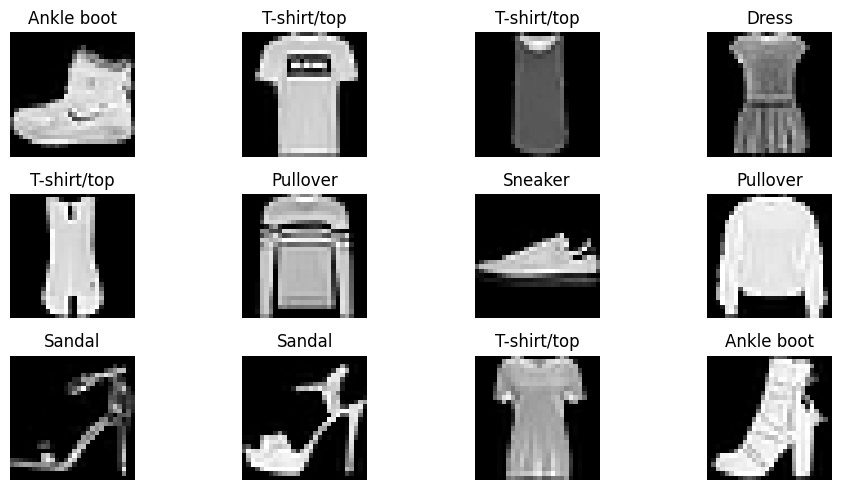

In [6]:
# Display first 12 images from training set

plt.figure(figsize=(10,5))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(X_train[i], cmap='gray')  # grayscale images
    plt.title(class_names[y_train[i]])   # remove [0]
    plt.axis('off')

plt.tight_layout()
plt.show()

## 3. Model Architecture

A Convolutional Neural Network (CNN) model is designed to classify images from the dataset. The model begins with two convolutional layers with the ReLU activation function, followed by a max-pooling layer.

The output is flattened and passed to a fully connected dense layer with 128 neurons and ReLU activation. A dropout layer with a rate of 0.3 is added to reduce overfitting and improve model generalization. An output layer with 10 neurons and a softmax activation function is used to classify the images into ten clothing categories.

The model is compiled using the **Adam** optimizer, **sparse categorical cross-entropy** loss function, and **accuracy** as the evaluation metric. The network is trained for **10** epochs with a batch size of **64**.

### 3.1 CNN Model

In [7]:
model = models.Sequential([

    # Convolution Layer 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    # Convolution Layer 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

/home/rajat/nlp_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-24 10:47:02.580424: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### 3.2 Compile Model

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 3.3 Train Model 

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.7915 - loss: 0.5788 - val_accuracy: 0.8657 - val_loss: 0.3736
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - accuracy: 0.8654 - loss: 0.3720 - val_accuracy: 0.8855 - val_loss: 0.3192
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.8817 - loss: 0.3221 - val_accuracy: 0.8926 - val_loss: 0.2862
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.8942 - loss: 0.2900 - val_accuracy: 0.8982 - val_loss: 0.2746
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.9003 - loss: 0.2699 - val_accuracy: 0.9019 - val_loss: 0.2631
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.9066 - loss: 0.2504 - val_accuracy: 0.9062 - val_loss: 0.2538
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 52ms/step - accuracy: 0.9142 - loss: 0.2316 - val_accuracy: 0.9105 - val_loss: 0.2466
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.9176 - loss: 0.2182 - 

### 3.4 Evaluate Model

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9070 - loss: 0.2581
Test Accuracy: 0.9070000052452087
Test Loss: 0.25811612606048584


- Test accuracy of this model we got is approximately 91%.

### 3.5 Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


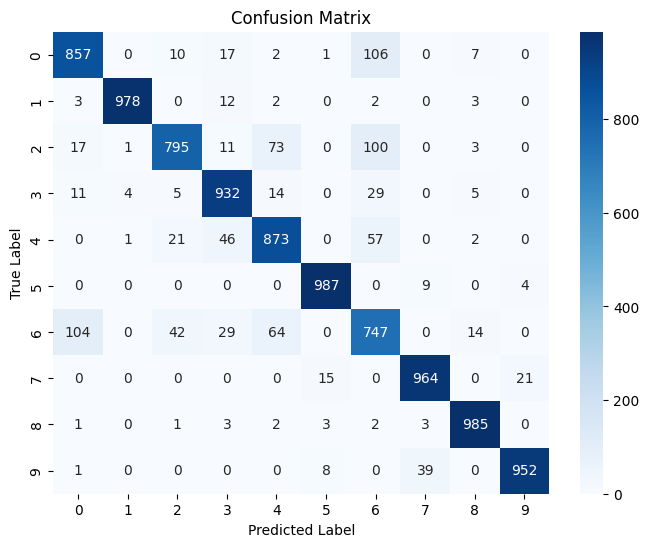

In [11]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

- Most values are concentrated along the diagonal, which indicates that the model performs well overall, achieving strong classification accuracy across most categories.

### 3.6 Classification Report

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1000
           1       0.99      0.98      0.99      1000
           2       0.91      0.80      0.85      1000
           3       0.89      0.93      0.91      1000
           4       0.85      0.87      0.86      1000
           5       0.97      0.99      0.98      1000
           6       0.72      0.75      0.73      1000
           7       0.95      0.96      0.96      1000
           8       0.97      0.98      0.98      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### 3.7 Accuracy Curve

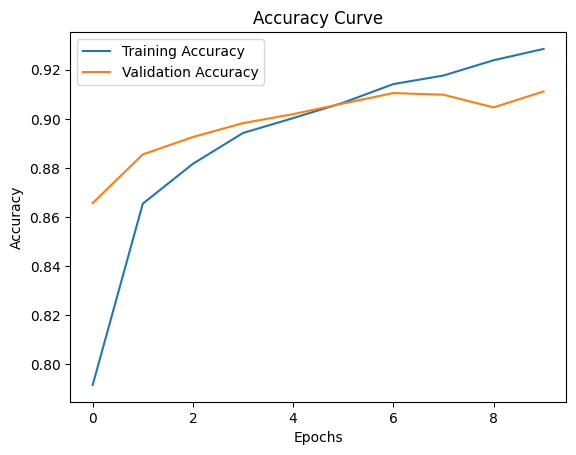

In [13]:
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

### 3.8 Loss Curve

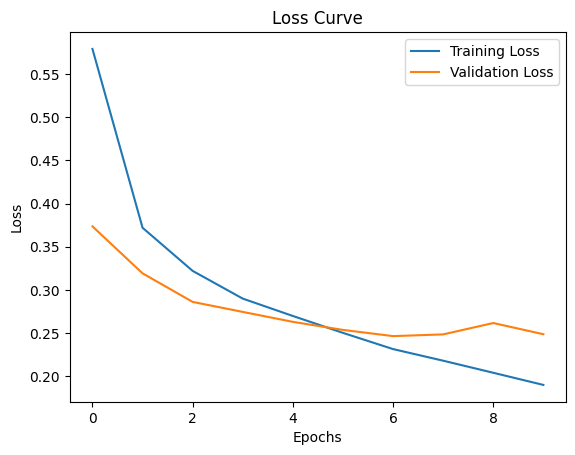

In [14]:
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

## 4. Hyperparameter Tuning
- In hyperparametr tuning we set dropout 0.3 instead of 0.2 and optimizer = RMSprop

In [15]:
model_hp = models.Sequential([

    # Convolution Layer 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    # Convolution Layer 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    

    # Output Layer
    layers.Dense(10, activation='softmax')
])

/home/rajat/nlp_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 4.1 Compile Model

In [16]:
model_hp.compile(
    optimizer='RMSprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_hp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 4.2 Train hyperparameter tuning model

In [17]:
history_hp = model_hp.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7815 - loss: 0.6038 - val_accuracy: 0.8571 - val_loss: 0.3930
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.8610 - loss: 0.3850 - val_accuracy: 0.8823 - val_loss: 0.3166
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - accuracy: 0.8819 - loss: 0.3301 - val_accuracy: 0.8914 - val_loss: 0.3053
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 51ms/step - accuracy: 0.8940 - loss: 0.2971 - val_accuracy: 0.9000 - val_loss: 0.2758
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 32s 43ms/step - accuracy: 0.9021 - loss: 0.2706 - val_accuracy: 0.9045 - val_loss: 0.2670
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 33s 45ms/step - accuracy: 0.9087 - loss: 0.2537 - val_accuracy: 0.9016 - val_loss: 0.2747
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 65ms/step - accuracy: 0.9144 - loss: 0.2399 - val_accuracy: 0.9093 - val_loss: 0.2615
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 75s 51ms/step - accuracy: 0.9183 - loss: 0.2275 - 

### 4.3 Evaluate hyperparameter tuning model

In [18]:
test_loss, test_acc = model_hp.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9018 - loss: 0.2807
Test Accuracy: 0.9017999768257141
Test Loss: 0.2806658148765564


- To improve the performance of the CNN model, hyperparameter tuning was performed by modifying the optimizer and dropout rate. In the baseline model, the Adam optimizer was used with a dropout rate of 0.2. In the tuned model, the optimizer was changed to RMSprop, and the dropout rate was increased to 0.3 to reduce overfitting and improve model generalization.

- After applying these changes, the model performance was evaluated again and compared with the baseline CNN model. The results showed a slight improvement in classification accuracy, indicating that the updated hyperparameters helped the model learn more effectively from the dataset.

## 5. Batch Normalization
- To further improve the performance of the CNN model, Batch Normalization was added after the convolutional layers. Batch normalization helps stabilize the learning process by normalizing the intermediate outputs of each layer, which allows the model to train faster and reduces the chances of overfitting.

In [19]:
# Building a new CNN model with Batch Normalization
model_bn = models.Sequential()

# First convolutional layer with Batch Normalization
model_bn.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))
model_bn.add(layers.BatchNormalization())
model_bn.add(layers.MaxPooling2D((2, 2)))

# Second convolutional layer with Batch Normalization
model_bn.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model_bn.add(layers.BatchNormalization())
model_bn.add(layers.MaxPooling2D((2, 2)))

# Dropout layer to reduce overfitting
model_bn.add(layers.Dropout(0.25))

# Flatten the feature maps to 1D
model_bn.add(layers.Flatten())

# Fully connected layer (dense layer)
model_bn.add(layers.Dense(64, activation='relu'))

# Output layer for classification (10 classes)
model_bn.add(layers.Dense(10, activation='softmax'))

# Compile the model
model_bn.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# Summary of the new model
model_bn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,618 (861.79 KB)

 Trainable params: 220,426 (861.04 KB)

 Non-trainable params: 192 (768.00 B)

### 5.1 Train Batch Normalization model

In [20]:
history_bn = model_bn.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 95s 98ms/step - accuracy: 0.8549 - loss: 0.4077 - val_accuracy: 0.8867 - val_loss: 0.3157
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 87s 93ms/step - accuracy: 0.9021 - loss: 0.2687 - val_accuracy: 0.8762 - val_loss: 0.3287
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 88s 94ms/step - accuracy: 0.9149 - loss: 0.2309 - val_accuracy: 0.8991 - val_loss: 0.2679
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 73s 78ms/step - accuracy: 0.9210 - loss: 0.2107 - val_accuracy: 0.8715 - val_loss: 0.3433
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 77ms/step - accuracy: 0.9308 - loss: 0.1864 - val_accuracy: 0.9103 - val_loss: 0.2409
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.9346 - loss: 0.1746 - val_accuracy: 0.9110 - val_loss: 0.2457
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 87s 85ms/step - accuracy: 0.9400 - loss: 0.1617 - val_accuracy: 0.9030 - val_loss: 0.2744
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.9449 - loss: 0.1455 - 

### 5.2 Evaluate Batch Normalization Model

In [21]:
test_loss, test_acc = model_bn.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9202 - loss: 0.2425
Test Accuracy: 0.920199990272522
Test Loss: 0.2424573451280594


- After including batch normalization layers, the model showed better classification performance compared to the baseline CNN model and the hyperparameter-tuned model with RMSprop and dropout. 

### 5.3 Plot Accuracy & Loss Curves from batch normalization model

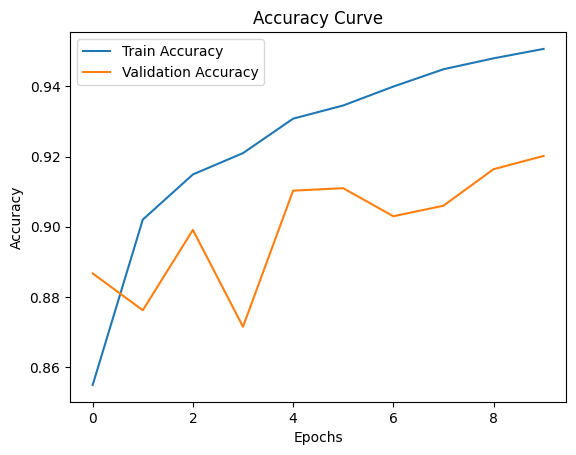

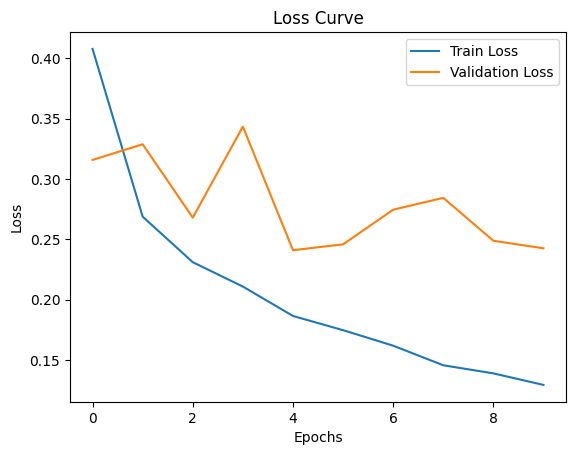

In [22]:
# Accuracy Plot
plt.plot(history_bn.history['accuracy'], label='Train Accuracy')
plt.plot(history_bn.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Plot
plt.plot(history_bn.history['loss'], label='Train Loss')
plt.plot(history_bn.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

- The accuracy curve shows that the training accuracy increases steadily from about 86% to 95%, which indicates that the model is learning effectively from the training data. The validation accuracy also improves during the initial epochs and stabilizes around 91%–92%, showing good generalization performance. <br>
- The loss curve shows that the training loss decreases continuously across epochs, which confirms that the model is learning patterns effectively.This increase in validation loss while training loss continues decreasing is another indication of minor overfitting after the middle training stages.

## 6. Comparison of best model

In [23]:
models_dict = {

    "CNN (Adam Optimizer)": model,
    "CNN (RMSprop Optimizer)": model_hp,
    "CNN with Batch Normalization": model_bn
}

results = []

for name, m in models_dict.items():

    loss, acc = m.evaluate(X_test, y_test, verbose=0)

    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,CNN with Batch Normalization,0.9202
0,CNN (Adam Optimizer),0.9070
1,CNN (RMSprop Optimizer),0.9018


- The batch normalization model achieved the highest accuracy among all tested models, indicating that it improved feature learning and overall model generalization on the Fashion-MNIST dataset.

## 7. Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


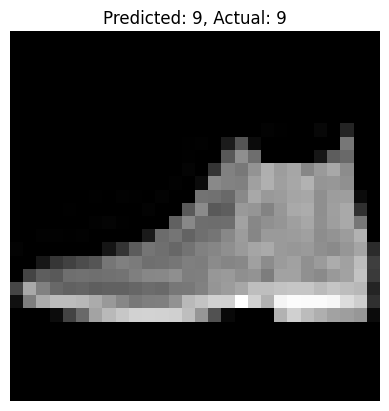

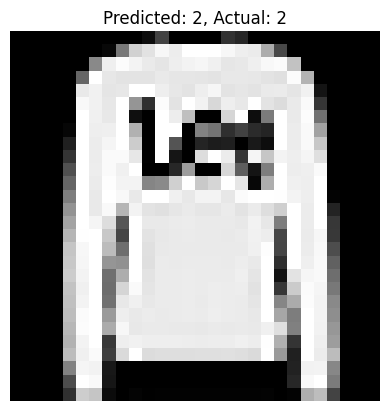

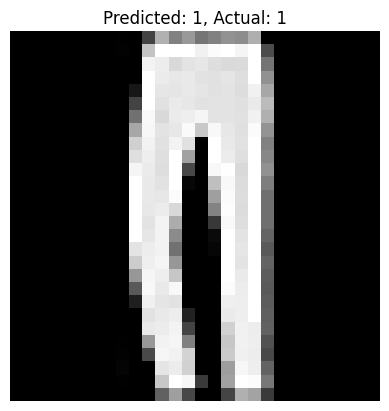

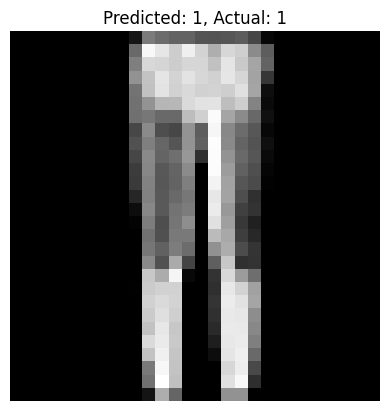

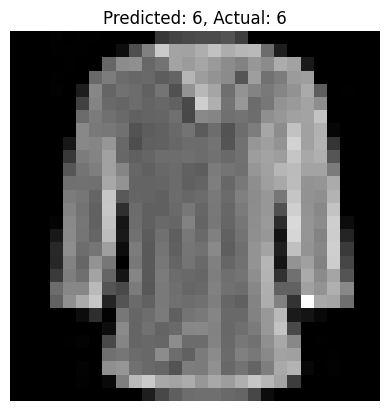

In [28]:
predictions = model_bn.predict(X_test[:5])

for i in range(5):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[i])}, Actual: {y_test[i]}")
    plt.axis('off')
    plt.show()

- The prediction results show that the model correctly classified most of the clothing images with high accuracy.

## 8. Conclusion

- In this project, a Convolutional Neural Network (CNN) was implemented to classify images from the Fashion-MNIST dataset. The dataset was first explored through sample visualization, and a baseline CNN model was trained to evaluate its performance using accuracy, confusion matrix, and learning curves.
- Further improvements were attempted through hyperparameter tuning by changing the optimizer to RMSprop and adjusting the dropout value, but these changes did not significantly improve the results. After that, a CNN model with batch normalization was developed, which showed better performance compared to the previous models. Among all the tested approaches, the batch normalization model achieved the highest accuracy and provided more stable learning behavior.
- Overall, the results demonstrate that CNN models are effective for image classification tasks, and techniques such as batch normalization can help improve model performance and generalization on the Fashion-MNIST dataset.